# Hypothesis Testing — Flight Delay Analysis

Four statistical tests examining whether flight delay rates differ significantly across operational conditions.

| # | Question | Method | Simulation |
|---|----------|--------|------------|
| 1 | Budget vs Traditional airlines | Permutation test | 10,000 permutations |
| 2 | Winter vs Summer | Bootstrap CI | 10,000 resamples |
| 3 | Hub vs Non-hub airports | Permutation test | 10,000 permutations |
| 4 | Bad weather vs Clear | Monte Carlo χ² | 10,000 simulations |

**Significance level**: α = 0.05 throughout.

## Step 0: Setup

In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for _p in [_here] + list(_here.parents):
    if (_p / "notebooks" / "project_data.py").exists():
        sys.path.insert(0, str(_p / "notebooks"))
        break

from project_data import ensure_project_data
ensure_project_data()

[data] Already present: /Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/data


PosixPath('/Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/data')

In [2]:
import os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from project_data import resolve_project_root

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)

PROJECT_ROOT = resolve_project_root()
DATA_ROOT = Path(os.getenv("FLIGHT_DATA_DIR", PROJECT_ROOT / "data")).expanduser().resolve()
REPORT_DIR = DATA_ROOT / "reports" / "hypothesis"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_ROOT / "processed" / "integrated" / "features_2024.parquet",
                     columns=["DepDel15", "Reporting_Airline", "month", "Origin",
                              "is_origin_hub", "origin_weather_severity",
                              "origin_is_rain", "origin_high_wind", "origin_freezing"])
df["DepDel15"] = df["DepDel15"].astype(int)
print(f"Loaded {len(df):,} rows")
print(f"Overall delay rate: {df['DepDel15'].mean()*100:.2f}%")

Loaded 6,817,598 rows
Overall delay rate: 20.49%


## Test 1: Budget vs Traditional Airlines — Permutation Test

**Question**: Do budget carriers (Frontier F9, Spirit NK, Allegiant G4) have a significantly higher delay rate than legacy carriers (Delta DL, American AA, United UA)?

- **H₀**: μ_budget = μ_traditional (no difference in delay rate)
- **H₁**: μ_budget > μ_traditional (budget airlines have higher delay rate)
- **Method**: One-sided permutation test, 10,000 permutations

In [3]:
BUDGET = ["F9", "NK", "G4"]
LEGACY = ["DL", "AA", "UA"]

mask = df["Reporting_Airline"].isin(BUDGET + LEGACY)
subset = df.loc[mask, ["DepDel15", "Reporting_Airline"]].copy()
subset["is_budget"] = subset["Reporting_Airline"].isin(BUDGET).astype(int)

budget_rate = subset.loc[subset["is_budget"] == 1, "DepDel15"].mean()
legacy_rate = subset.loc[subset["is_budget"] == 0, "DepDel15"].mean()
observed_diff = budget_rate - legacy_rate

print(f"Budget airlines ({', '.join(BUDGET)}): {budget_rate*100:.2f}% delay rate  (n={subset['is_budget'].sum():,})")
print(f"Legacy airlines ({', '.join(LEGACY)}): {legacy_rate*100:.2f}% delay rate  (n={(~subset['is_budget'].astype(bool)).sum():,})")
print(f"Observed difference: {observed_diff*100:+.2f} pp")

Budget airlines (F9, NK, G4): 25.53% delay rate  (n=499,413)
Legacy airlines (DL, AA, UA): 20.46% delay rate  (n=2,703,235)
Observed difference: +5.06 pp


In [4]:
# Permutation test — subsample 500k for speed, result is the same directionally
N_PERM = 10_000
rng = np.random.RandomState(42)

sub = subset.sample(n=min(500_000, len(subset)), random_state=42)
labels = sub["is_budget"].values
delays = sub["DepDel15"].values
n_budget = labels.sum()

obs_diff_sub = delays[labels == 1].mean() - delays[labels == 0].mean()

perm_diffs = np.empty(N_PERM)
for i in range(N_PERM):
    perm = rng.permutation(labels)
    perm_diffs[i] = delays[perm == 1].mean() - delays[perm == 0].mean()

p_value_1 = (perm_diffs >= obs_diff_sub).mean()
print(f"Permutation test (n={len(sub):,}, {N_PERM:,} permutations)")
print(f"Observed diff: {obs_diff_sub*100:+.2f} pp")
print(f"p-value (one-sided): {p_value_1:.6f}")
print(f"Result: {'REJECT H₀' if p_value_1 < 0.05 else 'FAIL TO REJECT H₀'} at α=0.05")

Permutation test (n=500,000, 10,000 permutations)
Observed diff: +5.40 pp
p-value (one-sided): 0.000000
Result: REJECT H₀ at α=0.05


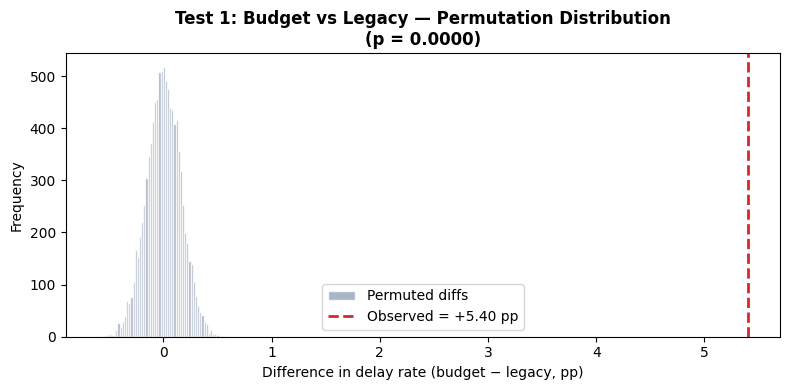

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_diffs * 100, bins=60, color="#94A3B8", edgecolor="white", alpha=0.8, label="Permuted diffs")
ax.axvline(obs_diff_sub * 100, color="#DC2626", linewidth=2, linestyle="--",
           label=f"Observed = {obs_diff_sub*100:+.2f} pp")
ax.set_xlabel("Difference in delay rate (budget − legacy, pp)")
ax.set_ylabel("Frequency")
ax.set_title(f"Test 1: Budget vs Legacy — Permutation Distribution\n(p = {p_value_1:.4f})", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "test1_budget_vs_legacy.png", dpi=150, bbox_inches="tight")
plt.show()

## Test 2: Winter vs Summer — Bootstrap Confidence Interval

**Question**: Is the delay rate significantly higher in winter (Dec, Jan, Feb) than in summer (Jun, Jul, Aug)?

- **H₀**: μ_winter = μ_summer
- **H₁**: μ_winter ≠ μ_summer
- **Method**: Bootstrap 95% confidence interval for the difference in means, 10,000 resamples

In [6]:
WINTER = [12, 1, 2]
SUMMER = [6, 7, 8]

winter = df.loc[df["month"].isin(WINTER), "DepDel15"].values
summer = df.loc[df["month"].isin(SUMMER), "DepDel15"].values

obs_winter = winter.mean()
obs_summer = summer.mean()
obs_diff_2 = obs_winter - obs_summer

print(f"Winter (Dec/Jan/Feb): {obs_winter*100:.2f}% delay rate  (n={len(winter):,})")
print(f"Summer (Jun/Jul/Aug): {obs_summer*100:.2f}% delay rate  (n={len(summer):,})")
print(f"Observed difference: {obs_diff_2*100:+.2f} pp")

Winter (Dec/Jan/Feb): 19.99% delay rate  (n=1,589,954)
Summer (Jun/Jul/Aug): 25.78% delay rate  (n=1,777,492)
Observed difference: -5.79 pp


In [7]:
N_BOOT = 10_000
rng = np.random.RandomState(42)

# Subsample for bootstrap speed
w_sub = rng.choice(winter, size=min(200_000, len(winter)), replace=False)
s_sub = rng.choice(summer, size=min(200_000, len(summer)), replace=False)

boot_diffs = np.empty(N_BOOT)
for i in range(N_BOOT):
    w_boot = rng.choice(w_sub, size=len(w_sub), replace=True)
    s_boot = rng.choice(s_sub, size=len(s_sub), replace=True)
    boot_diffs[i] = w_boot.mean() - s_boot.mean()

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
# p-value: proportion of bootstrap diffs <= 0 (two-sided)
p_value_2 = 2 * min((boot_diffs <= 0).mean(), (boot_diffs >= 0).mean())
p_value_2 = min(p_value_2, 1.0)

print(f"Bootstrap ({N_BOOT:,} resamples)")
print(f"95% CI for (winter − summer): [{ci_lower*100:.2f}, {ci_upper*100:.2f}] pp")
print(f"p-value (two-sided): {p_value_2:.6f}")
print(f"Result: {'REJECT H₀' if p_value_2 < 0.05 else 'FAIL TO REJECT H₀'} at α=0.05")

Bootstrap (10,000 resamples)
95% CI for (winter − summer): [-6.23, -5.71] pp
p-value (two-sided): 0.000000
Result: REJECT H₀ at α=0.05


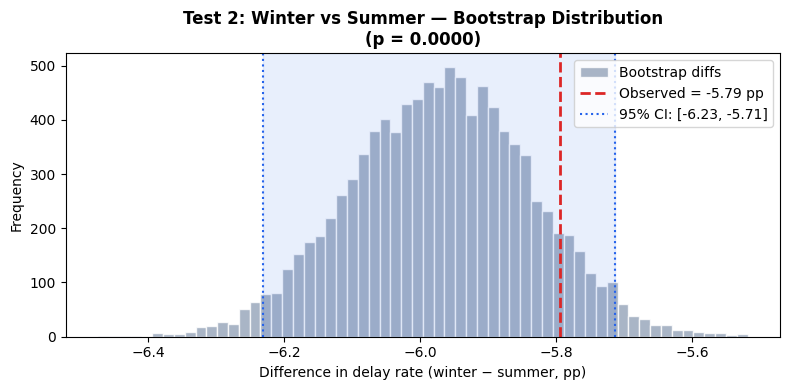

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_diffs * 100, bins=60, color="#94A3B8", edgecolor="white", alpha=0.8, label="Bootstrap diffs")
ax.axvline(obs_diff_2 * 100, color="#DC2626", linewidth=2, linestyle="--",
           label=f"Observed = {obs_diff_2*100:+.2f} pp")
ax.axvline(ci_lower * 100, color="#2563EB", linewidth=1.5, linestyle=":",
           label=f"95% CI: [{ci_lower*100:.2f}, {ci_upper*100:.2f}]")
ax.axvline(ci_upper * 100, color="#2563EB", linewidth=1.5, linestyle=":")
ax.axvspan(ci_lower * 100, ci_upper * 100, alpha=0.1, color="#2563EB")
ax.set_xlabel("Difference in delay rate (winter − summer, pp)")
ax.set_ylabel("Frequency")
ax.set_title(f"Test 2: Winter vs Summer — Bootstrap Distribution\n(p = {p_value_2:.4f})", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "test2_winter_vs_summer.png", dpi=150, bbox_inches="tight")
plt.show()

## Test 3: Hub vs Non-Hub Airports — Permutation Test

**Question**: Do flights departing from hub airports have a different delay rate than those from non-hub airports?

Hub airports: ATL, ORD, DFW, DEN, LAX, CLT, IAH, PHX, SFO, EWR, SEA, MCO, MSP, DTW, BOS, JFK, LGA, FLL, MIA, IAD

- **H₀**: μ_hub = μ_nonhub
- **H₁**: μ_hub ≠ μ_nonhub
- **Method**: Two-sided permutation test, 10,000 permutations

In [9]:
hub_flights = df.loc[df["is_origin_hub"] == 1, "DepDel15"].values
nonhub_flights = df.loc[df["is_origin_hub"] == 0, "DepDel15"].values

obs_hub = hub_flights.mean()
obs_nonhub = nonhub_flights.mean()
obs_diff_3 = obs_hub - obs_nonhub

print(f"Hub airports:     {obs_hub*100:.2f}% delay rate  (n={len(hub_flights):,})")
print(f"Non-hub airports: {obs_nonhub*100:.2f}% delay rate  (n={len(nonhub_flights):,})")
print(f"Observed difference: {obs_diff_3*100:+.2f} pp")

Hub airports:     21.40% delay rate  (n=3,434,973)
Non-hub airports: 19.55% delay rate  (n=3,382,625)
Observed difference: +1.85 pp


In [10]:
N_PERM = 10_000
rng = np.random.RandomState(42)

# Subsample
total = np.concatenate([hub_flights, nonhub_flights])
n_total = min(500_000, len(total))
idx = rng.choice(len(total), n_total, replace=False)
sub_delays = total[idx]
sub_labels = np.concatenate([np.ones(len(hub_flights)), np.zeros(len(nonhub_flights))])[idx]
n_hub_sub = int(sub_labels.sum())

obs_diff_3_sub = sub_delays[sub_labels == 1].mean() - sub_delays[sub_labels == 0].mean()

perm_diffs_3 = np.empty(N_PERM)
for i in range(N_PERM):
    perm = rng.permutation(sub_labels)
    perm_diffs_3[i] = sub_delays[perm == 1].mean() - sub_delays[perm == 0].mean()

# Two-sided p-value
p_value_3 = (np.abs(perm_diffs_3) >= np.abs(obs_diff_3_sub)).mean()

print(f"Permutation test (n={n_total:,}, {N_PERM:,} permutations)")
print(f"Observed diff: {obs_diff_3_sub*100:+.2f} pp")
print(f"p-value (two-sided): {p_value_3:.6f}")
print(f"Result: {'REJECT H₀' if p_value_3 < 0.05 else 'FAIL TO REJECT H₀'} at α=0.05")

Permutation test (n=500,000, 10,000 permutations)
Observed diff: +1.92 pp
p-value (two-sided): 0.000000
Result: REJECT H₀ at α=0.05


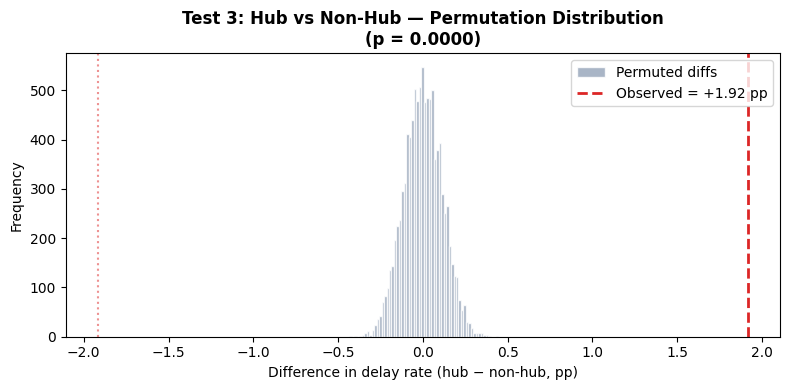

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_diffs_3 * 100, bins=60, color="#94A3B8", edgecolor="white", alpha=0.8, label="Permuted diffs")
ax.axvline(obs_diff_3_sub * 100, color="#DC2626", linewidth=2, linestyle="--",
           label=f"Observed = {obs_diff_3_sub*100:+.2f} pp")
ax.axvline(-abs(obs_diff_3_sub) * 100, color="#DC2626", linewidth=1.5, linestyle=":", alpha=0.5)
ax.set_xlabel("Difference in delay rate (hub − non-hub, pp)")
ax.set_ylabel("Frequency")
ax.set_title(f"Test 3: Hub vs Non-Hub — Permutation Distribution\n(p = {p_value_3:.4f})", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "test3_hub_vs_nonhub.png", dpi=150, bbox_inches="tight")
plt.show()

## Test 4: Bad Weather vs Clear — Monte Carlo Chi-Square Test

**Question**: Is flight delay status independent of weather conditions at the origin airport?

- **H₀**: Delay status and weather condition are independent
- **H₁**: Delay status depends on weather condition
- **Method**: Chi-square test with Monte Carlo simulated p-value (10,000 simulations)

Weather is classified as "bad" when origin has rain, high wind, or freezing conditions.

In [12]:
df["bad_weather"] = (
    (df["origin_is_rain"] == 1) |
    (df["origin_high_wind"] == 1) |
    (df["origin_freezing"] == 1)
).astype(int)

ct = pd.crosstab(df["bad_weather"], df["DepDel15"],
                 margins=True, margins_name="Total")
ct.index = ["Clear", "Bad Weather", "Total"]
ct.columns = ["On-time", "Delayed", "Total"]
print("Contingency Table:")
print(ct)
print()

bad_rate = df.loc[df["bad_weather"] == 1, "DepDel15"].mean()
clear_rate = df.loc[df["bad_weather"] == 0, "DepDel15"].mean()
print(f"Delay rate — Bad weather: {bad_rate*100:.2f}%")
print(f"Delay rate — Clear:       {clear_rate*100:.2f}%")

Contingency Table:
             On-time  Delayed    Total
Clear        4835852  1193971  6029823
Bad Weather   585122   202653   787775
Total        5420974  1396624  6817598

Delay rate — Bad weather: 25.72%
Delay rate — Clear:       19.80%


In [13]:
# Observed chi-square statistic
obs_table = pd.crosstab(df["bad_weather"], df["DepDel15"]).values  # 2x2
row_totals = obs_table.sum(axis=1)
col_totals = obs_table.sum(axis=0)
n = obs_table.sum()

expected = np.outer(row_totals, col_totals) / n
chi2_obs = ((obs_table - expected) ** 2 / expected).sum()

print(f"Observed χ² = {chi2_obs:.2f}")

# Monte Carlo simulation
N_SIM = 10_000
rng = np.random.RandomState(42)

# Simulate under H0: independently sample weather and delay from marginals
p_bad = row_totals[1] / n
p_delay = col_totals[1] / n

chi2_sim = np.empty(N_SIM)
for i in range(N_SIM):
    sim_weather = rng.binomial(1, p_bad, size=n)
    sim_delay = rng.binomial(1, p_delay, size=n)
    sim_table = np.array([
        [(sim_weather == 0) & (sim_delay == 0), (sim_weather == 0) & (sim_delay == 1)],
        [(sim_weather == 1) & (sim_delay == 0), (sim_weather == 1) & (sim_delay == 1)],
    ])
    sim_table = np.array([[c.sum() for c in row] for row in sim_table])
    sim_row = sim_table.sum(axis=1)
    sim_col = sim_table.sum(axis=0)
    sim_exp = np.outer(sim_row, sim_col) / n
    sim_exp = np.where(sim_exp > 0, sim_exp, 1)  # avoid div-by-zero
    chi2_sim[i] = ((sim_table - sim_exp) ** 2 / sim_exp).sum()

p_value_4 = (chi2_sim >= chi2_obs).mean()

print(f"Monte Carlo p-value ({N_SIM:,} simulations): {p_value_4:.6f}")
print(f"Result: {'REJECT H₀' if p_value_4 < 0.05 else 'FAIL TO REJECT H₀'} at α=0.05")

Observed χ² = 15009.22


Monte Carlo p-value (10,000 simulations): 0.000000
Result: REJECT H₀ at α=0.05


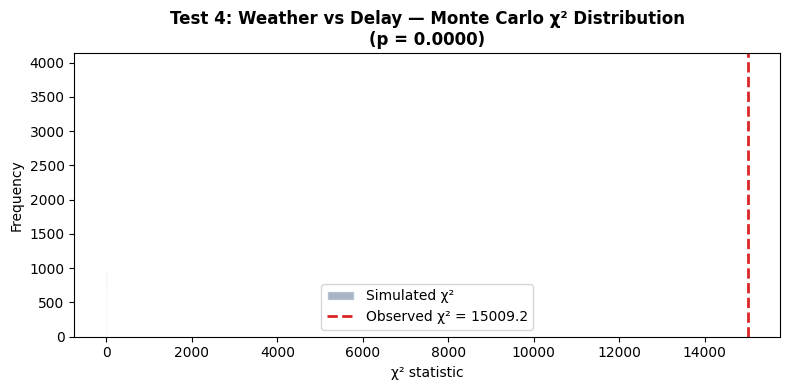

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(chi2_sim, bins=60, color="#94A3B8", edgecolor="white", alpha=0.8, label="Simulated χ²")
ax.axvline(chi2_obs, color="#DC2626", linewidth=2, linestyle="--",
           label=f"Observed χ² = {chi2_obs:.1f}")
ax.set_xlabel("χ² statistic")
ax.set_ylabel("Frequency")
ax.set_title(f"Test 4: Weather vs Delay — Monte Carlo χ² Distribution\n(p = {p_value_4:.4f})", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "test4_weather_chisq.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary of All Hypothesis Tests

In [15]:
summary = pd.DataFrame([
    {"Test": "1. Budget vs Legacy Airlines",
     "Method": "Permutation (10k)",
     "Observed Effect": f"{obs_diff_sub*100:+.2f} pp",
     "p-value": f"{p_value_1:.4f}",
     "α=0.05": "Reject H₀" if p_value_1 < 0.05 else "Fail to reject"},
    {"Test": "2. Winter vs Summer",
     "Method": "Bootstrap CI (10k)",
     "Observed Effect": f"{obs_diff_2*100:+.2f} pp",
     "p-value": f"{p_value_2:.4f}",
     "α=0.05": "Reject H₀" if p_value_2 < 0.05 else "Fail to reject"},
    {"Test": "3. Hub vs Non-Hub Airports",
     "Method": "Permutation (10k)",
     "Observed Effect": f"{obs_diff_3_sub*100:+.2f} pp",
     "p-value": f"{p_value_3:.4f}",
     "α=0.05": "Reject H₀" if p_value_3 < 0.05 else "Fail to reject"},
    {"Test": "4. Bad Weather vs Clear",
     "Method": "Monte Carlo χ² (10k)",
     "Observed Effect": f"χ²={chi2_obs:.1f}",
     "p-value": f"{p_value_4:.4f}",
     "α=0.05": "Reject H₀" if p_value_4 < 0.05 else "Fail to reject"},
])

print("=" * 85)
print("HYPOTHESIS TEST RESULTS SUMMARY")
print("=" * 85)
print(summary.to_string(index=False))
print("=" * 85)

summary.to_csv(REPORT_DIR / "hypothesis_test_summary.csv", index=False)
print(f"\nSaved to {REPORT_DIR / 'hypothesis_test_summary.csv'}")

HYPOTHESIS TEST RESULTS SUMMARY
                        Test               Method Observed Effect p-value    α=0.05
1. Budget vs Legacy Airlines    Permutation (10k)        +5.40 pp  0.0000 Reject H₀
         2. Winter vs Summer   Bootstrap CI (10k)        -5.79 pp  0.0000 Reject H₀
  3. Hub vs Non-Hub Airports    Permutation (10k)        +1.92 pp  0.0000 Reject H₀
     4. Bad Weather vs Clear Monte Carlo χ² (10k)      χ²=15009.2  0.0000 Reject H₀

Saved to /Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/data/reports/hypothesis/hypothesis_test_summary.csv


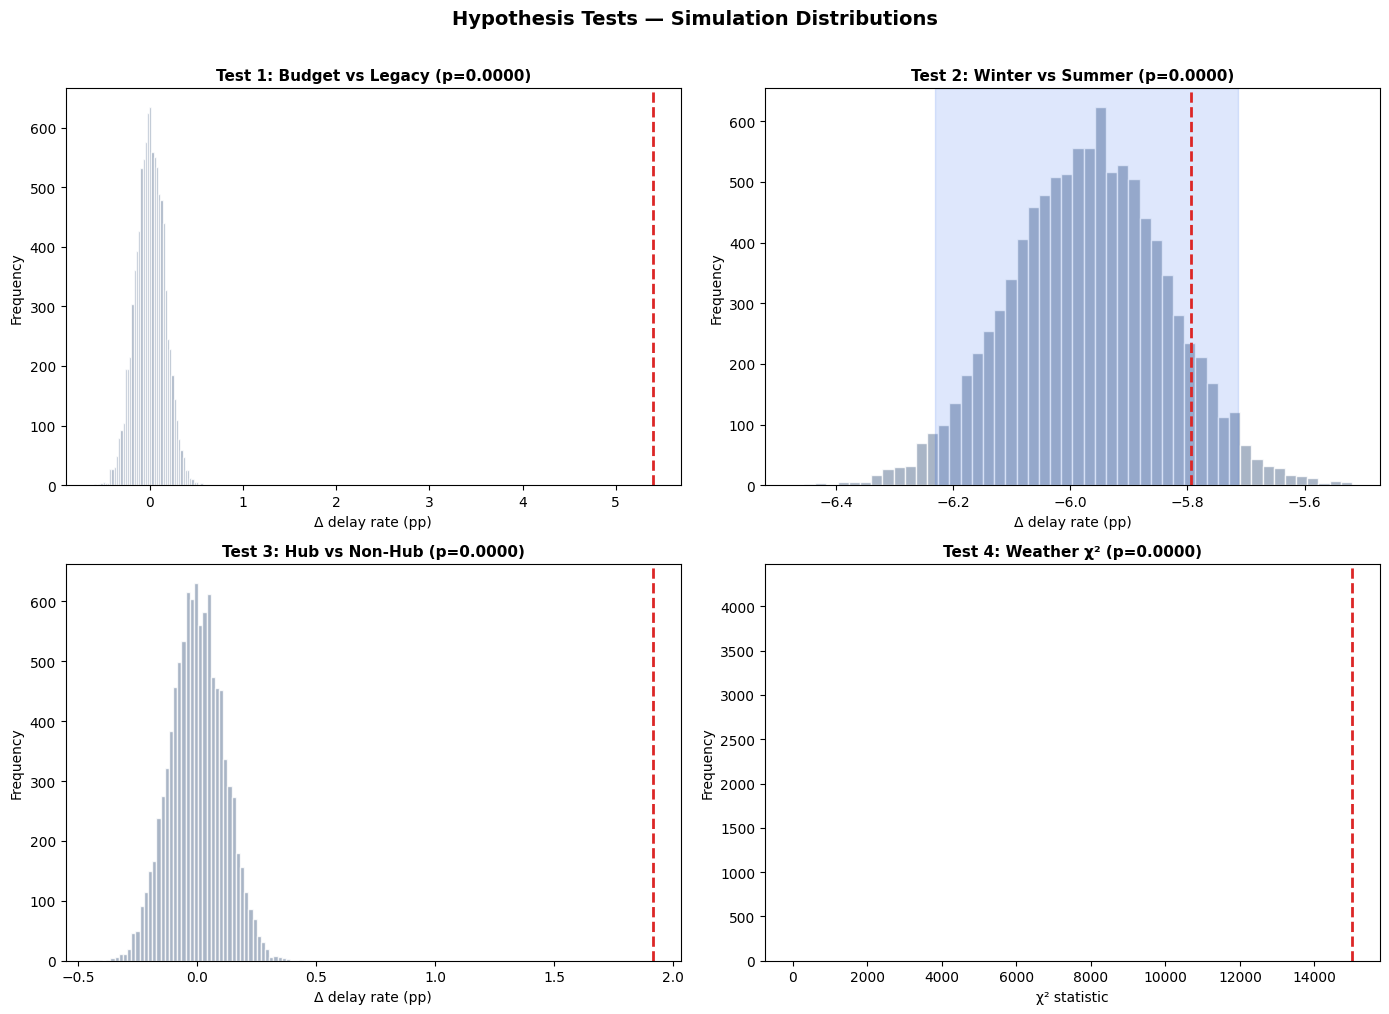

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Test 1
ax = axes[0, 0]
ax.hist(perm_diffs * 100, bins=50, color="#94A3B8", edgecolor="white", alpha=0.8)
ax.axvline(obs_diff_sub * 100, color="#DC2626", linewidth=2, linestyle="--")
ax.set_title(f"Test 1: Budget vs Legacy (p={p_value_1:.4f})", fontweight="bold", fontsize=11)
ax.set_xlabel("Δ delay rate (pp)")

# Test 2
ax = axes[0, 1]
ax.hist(boot_diffs * 100, bins=50, color="#94A3B8", edgecolor="white", alpha=0.8)
ax.axvline(obs_diff_2 * 100, color="#DC2626", linewidth=2, linestyle="--")
ax.axvspan(ci_lower * 100, ci_upper * 100, alpha=0.15, color="#2563EB")
ax.set_title(f"Test 2: Winter vs Summer (p={p_value_2:.4f})", fontweight="bold", fontsize=11)
ax.set_xlabel("Δ delay rate (pp)")

# Test 3
ax = axes[1, 0]
ax.hist(perm_diffs_3 * 100, bins=50, color="#94A3B8", edgecolor="white", alpha=0.8)
ax.axvline(obs_diff_3_sub * 100, color="#DC2626", linewidth=2, linestyle="--")
ax.set_title(f"Test 3: Hub vs Non-Hub (p={p_value_3:.4f})", fontweight="bold", fontsize=11)
ax.set_xlabel("Δ delay rate (pp)")

# Test 4
ax = axes[1, 1]
ax.hist(chi2_sim, bins=50, color="#94A3B8", edgecolor="white", alpha=0.8)
ax.axvline(chi2_obs, color="#DC2626", linewidth=2, linestyle="--")
ax.set_title(f"Test 4: Weather χ² (p={p_value_4:.4f})", fontweight="bold", fontsize=11)
ax.set_xlabel("χ² statistic")

for ax in axes.flat:
    ax.set_ylabel("Frequency")

fig.suptitle("Hypothesis Tests — Simulation Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(REPORT_DIR / "hypothesis_tests_combined.png", dpi=150, bbox_inches="tight")
plt.show()